# 03 Discrete-Continuous Dynamic Programming

[![Code License: MIT](https://img.shields.io/badge/Code%20License-MIT-yellow.svg)](LICENSE) [![Content License: CC BY 4.0](https://img.shields.io/badge/Content%20License-CC%20BY%204.0-blue.svg)](https://creativecommons.org/licenses/by/4.0/)

# 03_Discrete_Continuous_DP

[![Code License: MIT](https://img.shields.io/badge/Code%20License-MIT-yellow.svg)](../LICENSE)

[![Content License: CC BY 4.0](https://img.shields.io/badge/Content%20License-CC%20BY%204.0-blue.svg)](https://creativecommons.org/licenses/by/4.0/)

In [1]:
# === Environment Setup ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize_scalar
from scipy.interpolate import interp1d
from IPython.display import display, Markdown

# --- Configuration ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'figure.figsize': (11, 7), 'figure.dpi': 130})
np.set_printoptions(suppress=True, linewidth=120, precision=4)

print("Environment initialized.")

Environment initialized.


## Part 3: Dynamic Models
## Chapter 3.3: Discrete-Continuous Dynamic Programming

### Table of Contents
1.  [The Lens: Mixed Decisions](#The-Lens:-Mixed-Decisions)
2.  [The Rust (1987) Model: Optimal Replacement](#The-Rust-(1987)-Model:-Optimal-Replacement)
3.  [Continuous State DP: Consumption-Savings](#Continuous-State-DP:-Consumption-Savings)
4.  [Solving Continuous DP with Interpolation](#Solving-Continuous-DP-with-Interpolation)
5.  [Summary](#Summary)

# The Lens: Mixed Decisions

**What problem are we solving?**
Many economic problems involve both **discrete choices** (e.g., work/retire, buy/rent, default/repay) and **continuous choices** (e.g., how much to consume, how much to save). These "discrete-continuous" problems are ubiquitous in labor economics and corporate finance. Additionally, even pure continuous problems (like the Neoclassical Growth Model) often require solutions over a continuous state space, rather than a discrete grid, to achieve high accuracy.

**Why this method?**
The presence of discrete choices introduces "kinks" or non-concavities in the value function, breaking standard derivative-based optimization methods. Furthermore, solving for continuous states (like capital $k$) on a discrete grid creates discretization error. We need specialized approaches:
1.  **Conditional Value Functions:** Calculate the value of *each* discrete choice (e.g., $V_{work}$ and $V_{retire}$) assuming optimal continuous choices.
2.  **Interpolation:** Use function approximation (linear or spline interpolation) to evaluate the value function off-grid, allowing for continuous state variables.

This notebook demonstrates both techniques: first, the discrete choice logic using the canonical Rust (1987) model, and second, the continuous state logic using a Consumption-Savings model with linear interpolation.

### 1. The Rust (1987) Model: Optimal Replacement

Rust's model provides a canonical example of a discrete choice DP problem. A manager, Harold Zurcher, must decide each period whether to replace a bus engine (`d=1`, a discrete choice) or to keep it and perform maintenance (`d=0`).

- **State Variable:** The state of the system is the odometer reading, `x`, which represents the engine's mileage.
- **Flow Utility:** The utility in a period depends on the maintenance cost, which is a function of mileage, and the operating costs.
- **Transition:** The mileage `x` evolves stochastically over time.

The manager's problem is to choose a sequence of replacement and maintenance decisions to minimize the total expected discounted cost over the infinite horizon.

#### The Conditional Value Function

The key to solving these models is to decompose the value function. The overall value function is:
$$ V(x) = \max_{d \in \{0, 1\}} \{ v(x, d) \} $$
where $v(x, d)$ is the **conditional value function**—the value of committing to the discrete choice `d`.

1.  **Value of Replacing (`d=1`):** If the manager replaces the engine, he pays a fixed replacement cost `RC` and gets a new engine with zero mileage. The value is:
    $$ v(x, 1) = -RC + \beta E[V(0)] $$

2.  **Value of Keeping (`d=0`):** If the manager keeps the engine, he pays maintenance cost $c(x)$ and moves to a new state $x'$.
    $$ v(x, 0) = -c(x) + \beta E[V(x') | x] $$

This structure creates a **nested fixed point problem**. To solve for the outer value function $V(x)$, we iterate on these conditional value functions.

In [2]:
class OptimalReplacement:
    """
    A class to solve the Rust (1987) optimal replacement problem using 
    Value Function Iteration.
    """
    def __init__(self, beta=0.9, RC=10, c_scale=0.01, max_mileage=100, n_states=100):
        self.beta = beta          # Discount factor
        self.RC = RC              # Replacement cost
        self.c_scale = c_scale    # Cost scale parameter
        self.n_states = n_states  # Number of grid points
        self.state_grid = np.arange(n_states)
        
        # Transition probability: mileage increases by 0, 1, or 2 units
        self.p = [0.1, 0.7, 0.2]
        self.P = self._build_transition_matrix()
        
        # Cost function: linear in mileage
        self.cost = self.c_scale * self.state_grid

    def _build_transition_matrix(self):
        """Constructs the transition matrix P[x, x']."""
        P = np.zeros((self.n_states, self.n_states))
        for i in range(self.n_states):
            for k, prob in enumerate(self.p):
                if i + k < self.n_states:
                    P[i, i+k] = prob
            # Absorbing state at the boundary
            P[i, -1] += 1 - np.sum(P[i, :])
        return P

    def solve(self, tol=1e-6, max_iter=1000):
        """Solves the model using Value Function Iteration."""
        V = np.zeros(self.n_states)
        
        for i in range(max_iter):
            # 1. Expected Value of future state
            EV = self.P @ V
            
            # 2. Conditional Value Functions
            # Value of Keeping (d=0)
            v_keep = -self.cost + self.beta * EV
            
            # Value of Replacing (d=1)
            v_replace = -self.RC + self.beta * V[0]
            
            # 3. Bellman Operator
            V_new = np.maximum(v_keep, v_replace)
            
            if np.max(np.abs(V_new - V)) < tol:
                return V_new, v_keep, v_replace
            V = V_new
            
        return V, v_keep, v_replace

model = OptimalReplacement(RC=8)
V, v_keep, v_replace = model.solve()

# Find the threshold state where optimal choice switches from Keep to Replace
policy = (v_replace > v_keep).astype(int)
threshold_state = np.argmax(policy)
print(f"Optimal Replacement Threshold: State {threshold_state} (Mileage {threshold_state})")

Optimal Replacement Threshold: State 89 (Mileage 89)


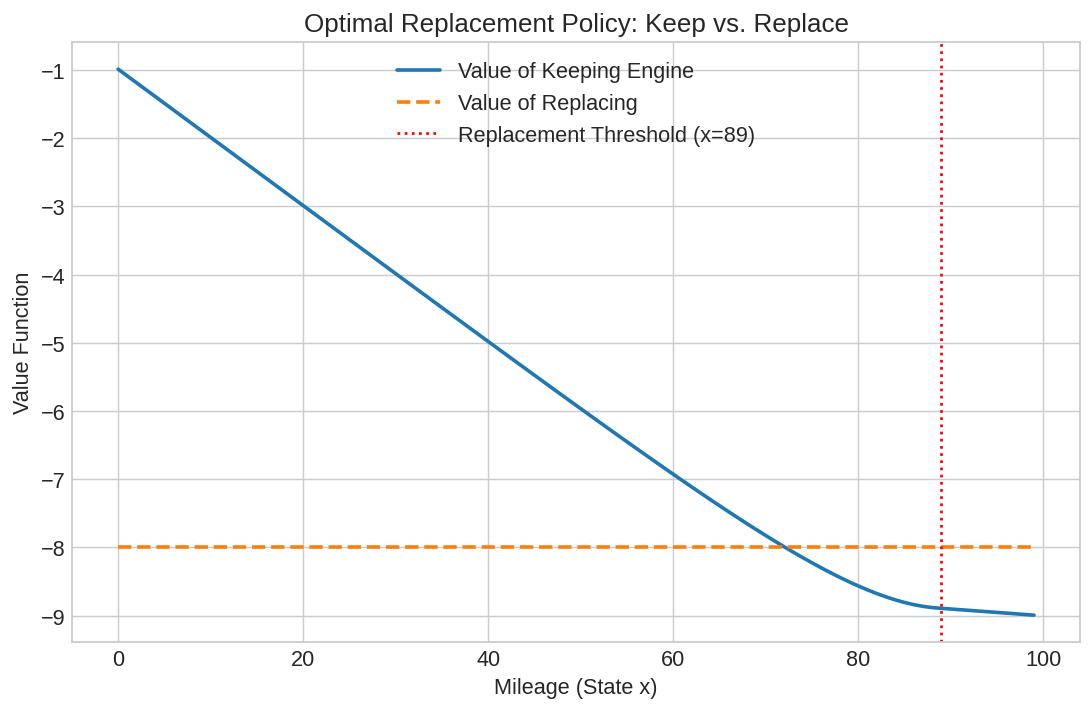

In [3]:
### Visualizing the Optimal Policy

plt.figure(figsize=(10, 6))
plt.plot(model.state_grid, v_keep, label='Value of Keeping Engine', linewidth=2)
plt.plot(model.state_grid, np.full_like(model.state_grid, v_replace), label='Value of Replacing', linestyle='--', linewidth=2)
plt.axvline(x=threshold_state, color='red', linestyle=':', label=f'Replacement Threshold (x={threshold_state})')

plt.title('Optimal Replacement Policy: Keep vs. Replace')
plt.xlabel('Mileage (State x)')
plt.ylabel('Value Function')
plt.legend()
plt.show()

### 2. Continuous State DP: Consumption-Savings

In the previous example, mileage was discrete. However, most macro variables (Capital, Assets) are continuous. Restricting them to a grid introduces errors.

Consider a household solving:
$$ V(k) = \max_{c, k'} \ln(c) + \beta V(k') $$
Subject to:
$$ c + k' = A k^\alpha + (1-\delta)k $$

If we force $k'$ to be on a grid, the agent cannot choose the true optimal $k'$. Using **linear interpolation**, we can evaluate $V(k')$ for *any* $k'$, allowing us to use continuous optimizers (like `minimize_scalar`).

In [4]:
class ContinuousDPSolver:
    """
    Solves a consumption-savings problem using VFI with Linear Interpolation.
    """
    def __init__(self, alpha=0.33, beta=0.96, delta=0.05, A=1.0, n_grid=50):
        self.alpha, self.beta, self.delta, self.A = alpha, beta, delta, A
        
        # Steady state capital (for grid centering)
        # 1 = beta * (alpha A k^(alpha-1) + 1 - delta)
        r_target = 1/beta - (1-delta)
        self.k_ss = (alpha * A / r_target)**(1/(1-alpha))
        
        # Create grid around steady state
        self.k_grid = np.linspace(0.5*self.k_ss, 1.5*self.k_ss, n_grid)
        self.V = np.zeros(n_grid) # Initial guess
        
    def utility(self, c):
        if c <= 0: return -1e10
        return np.log(c)
    
    def rhs(self, k, k_prime, V_interp):
        """Right Hand Side of Bellman: u(c) + beta * V(k')"""
        # Resource constraint: c = f(k) + (1-delta)k - k'
        production = self.A * k**self.alpha + (1-self.delta)*k
        c = production - k_prime
        
        if c <= 0:
            return -1e10
        
        # Value of next state (interpolated)
        # We handle extrapolation by clamping (safe for this convex problem)
        if k_prime < self.k_grid[0] or k_prime > self.k_grid[-1]:
            return -1e10 # Penalize going off grid
            
        v_next = V_interp(k_prime)
        return self.utility(c) + self.beta * v_next

    def solve(self, tol=1e-5, max_iter=200):
        V_old = np.copy(self.V)
        policy_k = np.zeros_like(self.k_grid)
        
        for i in range(max_iter):
            # Create interpolation function for current V
            V_interp = interp1d(self.k_grid, V_old, kind='linear', fill_value="extrapolate")
            V_new = np.zeros_like(V_old)
            
            for j, k in enumerate(self.k_grid):
                # Maximize RHS with respect to k_prime
                # Since optimizers minimize, we minimize -RHS
                production = self.A * k**self.alpha + (1-self.delta)*k
                bounds = (self.k_grid[0], min(production, self.k_grid[-1]))
                
                res = minimize_scalar(
                    lambda kp: -self.rhs(k, kp, V_interp),
                    bounds=bounds,
                    method='bounded'
                )
                
                V_new[j] = -res.fun
                policy_k[j] = res.x
            
            diff = np.max(np.abs(V_new - V_old))
            if diff < tol:
                print(f"Continuous VFI Converged in {i} iterations.")
                self.V = V_new
                self.policy = policy_k
                return
            
            V_old = V_new
            
        self.V = V_old
        self.policy = policy_k

cont_model = ContinuousDPSolver()
cont_model.solve()

<>:3: SyntaxWarning: invalid escape sequence '\p'
<>:9: SyntaxWarning: invalid escape sequence '\p'
<>:3: SyntaxWarning: invalid escape sequence '\p'
<>:9: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_32222/1435150602.py:3: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(cont_model.k_grid, cont_model.policy, label='Optimal Policy $k^\prime(k)$', linewidth=2)
/tmp/ipykernel_32222/1435150602.py:9: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('Next Period Capital $k^\prime$')


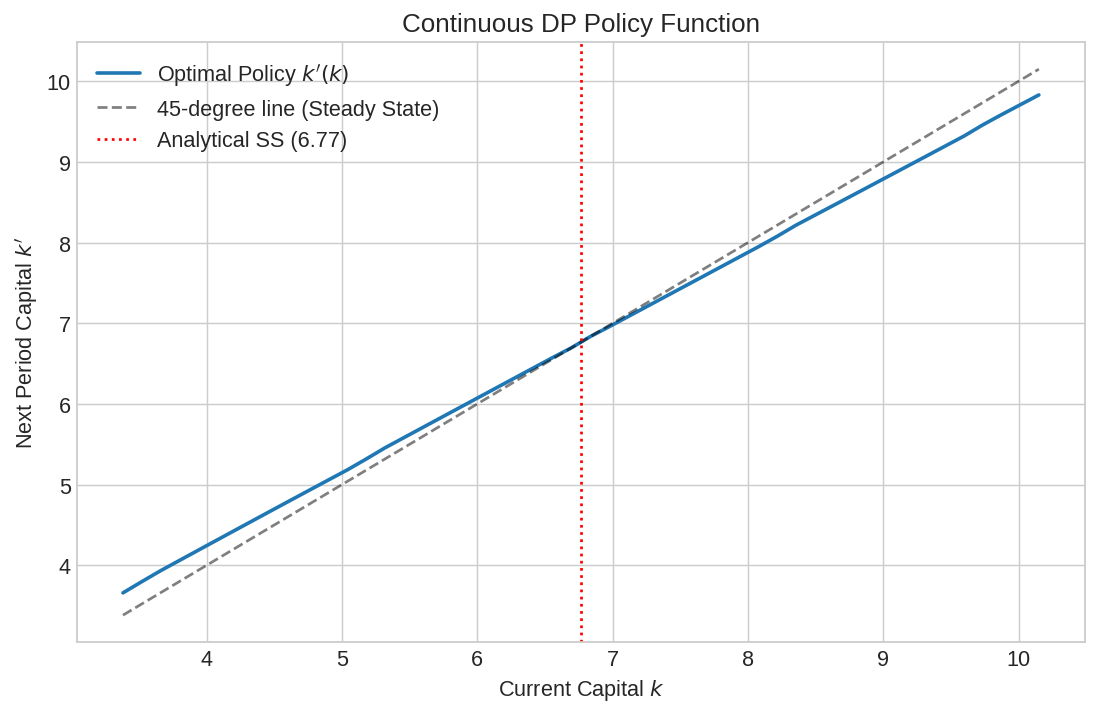

In [5]:
# Compare Policy Function with 45-degree line
plt.figure(figsize=(10, 6))
plt.plot(cont_model.k_grid, cont_model.policy, label='Optimal Policy $k^\prime(k)$', linewidth=2)
plt.plot(cont_model.k_grid, cont_model.k_grid, 'k--', label='45-degree line (Steady State)', alpha=0.5)
plt.axvline(cont_model.k_ss, color='red', linestyle=':', label=f'Analytical SS ({cont_model.k_ss:.2f})')

plt.title('Continuous DP Policy Function')
plt.xlabel('Current Capital $k$')
plt.ylabel('Next Period Capital $k^\prime$')
plt.legend()
plt.show()

# Summary

We have explored two advanced DP techniques:

1.  **Discrete Choice (Rust):** Solved by defining conditional value functions for each discrete alternative and taking the upper envelope. This handles the non-differentiability inherent in discrete choices.
2.  **Continuous States (Interpolation):** Solved by approximating the value function between grid points. This allows the agent to choose *any* real number for capital, eliminating the quantization error of grid-based methods and providing accurate steady-state values.